In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# Load the dataset
path = "motor_data11-14lats.csv"
df = pd.read_csv(path)

In [ ]:
df.head()


,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-13,07-AUG-14,08,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-12,07-AUG-13,08,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-11,07-AUG-12,08,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-JUL-11,07-AUG-11,08,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-13,07-AUG-14,08,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293537 entries, 0 to 293536
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                293537 non-null  int64  
 1   INSR_BEGIN         293537 non-null  object 
 2   INSR_END           293537 non-null  object 
 3   EFFECTIVE_YR       293536 non-null  object 
 4   INSR_TYPE          293537 non-null  int64  
 5   INSURED_VALUE      293537 non-null  float64
 6   PREMIUM            293529 non-null  float64
 7   OBJECT_ID          293537 non-null  int64  
 8   PROD_YEAR          293431 non-null  float64
 9   SEATS_NUM          293397 non-null  float64
 10  CARRYING_CAPACITY  212172 non-null  float64
 11  TYPE_VEHICLE       293537 non-null  object 
 12  CCM_TON            293535 non-null  float64
 13  MAKE               293537 non-null  object 
 14  USAGE              293537 non-null  object 
 15  CLAIM_PAID         22373 non-null   float64
dtypes:

In [ ]:
df.size

4696592

In [ ]:

df.columns = [c.strip().upper().replace(" ", "_") for c in df.columns]

print(df.columns.tolist())

['SEX', 'INSR_BEGIN', 'INSR_END', 'EFFECTIVE_YR', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID', 'PROD_YEAR', 'SEATS_NUM', 'CARRYING_CAPACITY', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE', 'CLAIM_PAID']


In [ ]:
# Convert to datetime so we can engineer features later (year/month/duration)
for col in ["INSR_BEGIN", "INSR_END"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

/tmp/ipykernel_386/3021891791.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipykernel_386/3021891791.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [ ]:
# 4) Convert numeric columns safely
numeric_cols = [
    "PREMIUM", "INSURED_VALUE", "SEATS_NUM", "CARRYING_CAPACITY",
    "CCM_TON", "PROD_YEAR", "EFFECTIVE_YR", "CLAIM_PAID"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [ ]:
# 5) Remove unusable rows for modelling
# PREMIUM is our target, so we must drop missing target rows.
df = df.dropna(subset=["PREMIUM"])

# Remove negative/zero premium values (not realistic for this context)
df = df[df["PREMIUM"] > 0]

print("Shape after removing missing/invalid PREMIUM:", df.shape)

Shape after removing missing/invalid PREMIUM: (293509, 16)


In [ ]:
# 6) Basic missing-value report (helps your methodology section)
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_report = missing_rate[missing_rate > 0].to_frame("missing_rate")
display(missing_report)


,missing_rate
CLAIM_PAID,0.923777
CARRYING_CAPACITY,0.277198
EFFECTIVE_YR,0.000920
SEATS_NUM,0.000477
PROD_YEAR,0.000361
CCM_TON,0.000007


In [ ]:
# Policy duration in days
if "INSR_BEGIN" in df.columns and "INSR_END" in df.columns:
    df["POLICY_DURATION_DAYS"] = (df["INSR_END"] - df["INSR_BEGIN"]).dt.days

    # Remove impossible durations (negative or extremely long)
    df.loc[(df["POLICY_DURATION_DAYS"] < 0) | (df["POLICY_DURATION_DAYS"] > 3660), "POLICY_DURATION_DAYS"] = np.nan

# Extract time features from INSR_BEGIN
if "INSR_BEGIN" in df.columns:
    df["BEGIN_YEAR"] = df["INSR_BEGIN"].dt.year
    df["BEGIN_MONTH"] = df["INSR_BEGIN"].dt.month

# Vehicle age (if production year exists)
if "PROD_YEAR" in df.columns and "INSR_BEGIN" in df.columns:
    df["VEHICLE_AGE"] = df["BEGIN_YEAR"] - df["PROD_YEAR"]

    # Remove unrealistic vehicle ages (negative or very high)
    df.loc[(df["VEHICLE_AGE"] < 0) | (df["VEHICLE_AGE"] > 50), "VEHICLE_AGE"] = np.nan



In [ ]:
df.head()  # After Cleaning

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID,POLICY_DURATION_DAYS,BEGIN_YEAR,BEGIN_MONTH,VEHICLE_AGE
0,0,2013-08-08,2014-08-07,8.0,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN,364.0,2013,8,6.0
1,0,2012-08-08,2013-08-07,8.0,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN,364.0,2012,8,5.0
2,0,2011-08-08,2012-08-07,8.0,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN,365.0,2011,8,4.0
3,0,2011-07-08,2011-08-07,8.0,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN,30.0,2011,7,4.0
4,0,2013-08-08,2014-08-07,8.0,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,364.0,2013,8,3.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:

df.columns = [c.strip().upper() for c in df.columns]
df["PREMIUM"] = pd.to_numeric(df["PREMIUM"], errors="coerce")
df = df.dropna(subset=["PREMIUM"])
df = df[df["PREMIUM"] > 0]

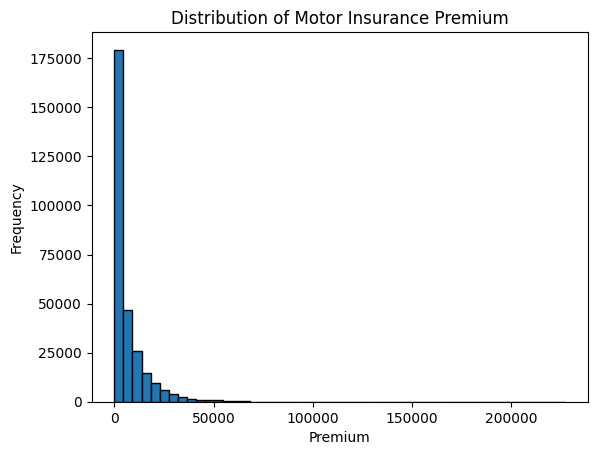

In [ ]:
plt.figure()
plt.hist(df["PREMIUM"], bins=50, edgecolor='black')
plt.title("Distribution of Motor Insurance Premium")
plt.xlabel("Premium")
plt.ylabel("Frequency")
plt.show()

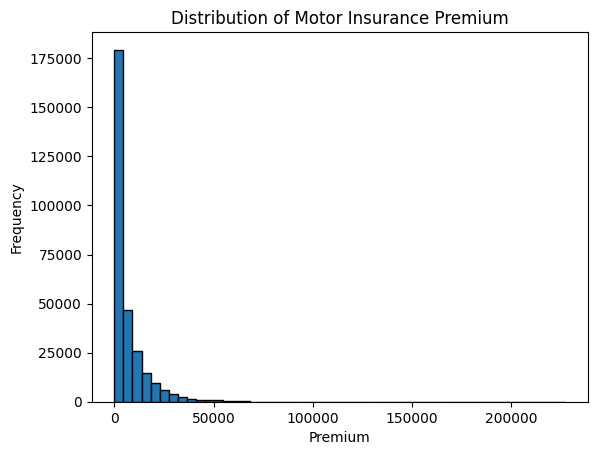

In [ ]:
plt.figure()
plt.hist(df["PREMIUM"], bins=50,edgecolor='black')
plt.title("Distribution of Motor Insurance Premium")
plt.xlabel("Premium")
plt.ylabel("Frequency")
plt.show()

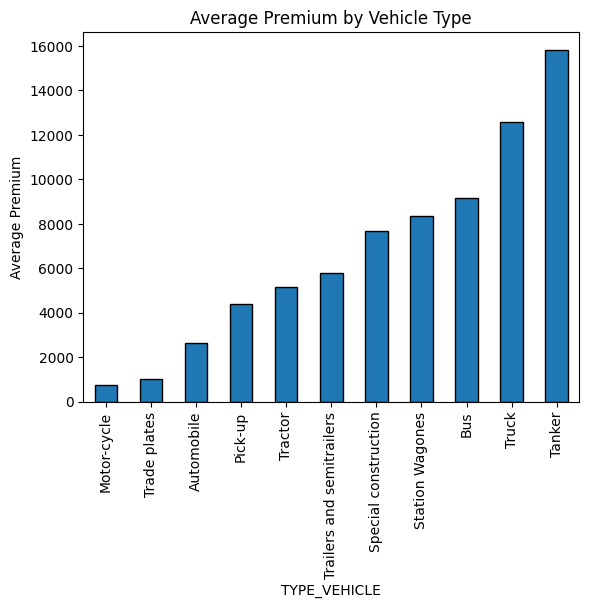

In [ ]:
if "TYPE_VEHICLE" in df.columns:
    avg_premium = df.groupby("TYPE_VEHICLE")["PREMIUM"].mean().sort_values()

    plt.figure()
    avg_premium.plot(kind="bar",edgecolor='black')
    plt.title("Average Premium by Vehicle Type")
    plt.ylabel("Average Premium")
    plt.show()

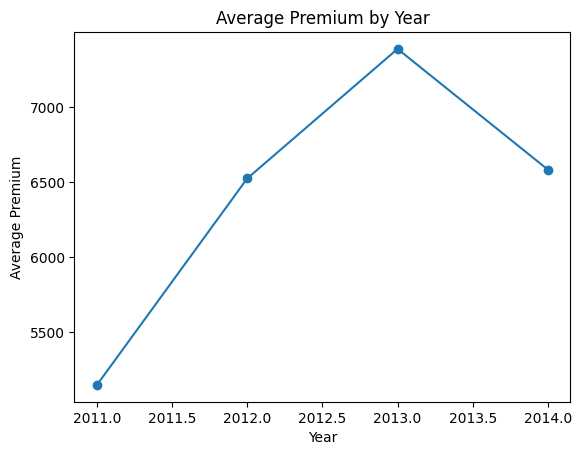

In [ ]:
if "INSR_BEGIN" in df.columns:
    df["INSR_BEGIN"] = pd.to_datetime(df["INSR_BEGIN"], errors="coerce")
    df["YEAR"] = df["INSR_BEGIN"].dt.year

    yearly_avg = df.groupby("YEAR")["PREMIUM"].mean()

    plt.figure()
    yearly_avg.plot(marker='o')
    plt.title("Average Premium by Year")
    plt.ylabel("Average Premium")
    plt.xlabel("Year")
    plt.show()

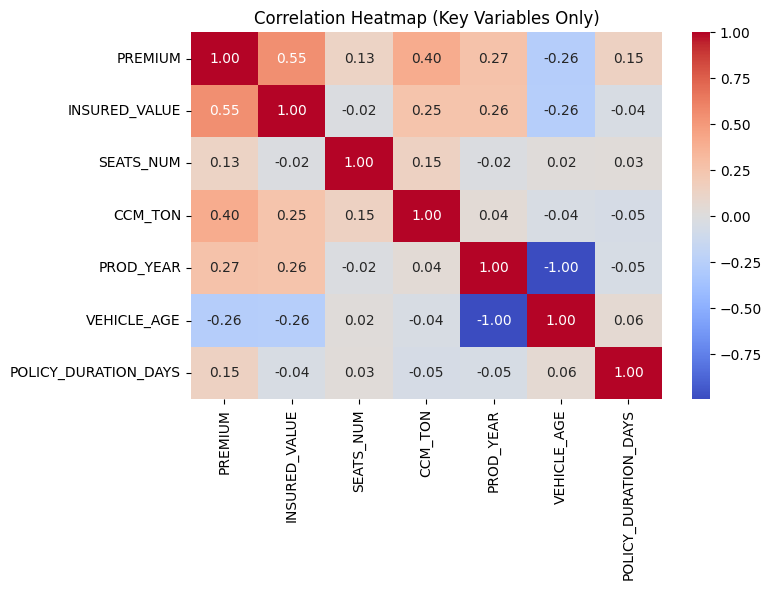

In [ ]:
import seaborn as sns

important_cols = [
    "PREMIUM",
    "INSURED_VALUE",
    "SEATS_NUM",
    "CCM_TON",
    "PROD_YEAR",
    "VEHICLE_AGE",
    "POLICY_DURATION_DAYS"
]

important_cols = [c for c in important_cols if c in df.columns]

corr_matrix = df[important_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Key Variables Only)")
plt.tight_layout()
plt.show()

In [ ]:
# Select useful columns for modelling
selected_features = [
    "INSURED_VALUE",
    "SEATS_NUM",
    "CCM_TON",
    "PROD_YEAR",
    "INSR_TYPE",
    "TYPE_VEHICLE",
    "USAGE"
]

# Keep only columns that actually exist in the dataset
selected_features = [col for col in selected_features if col in df.columns]

# Define input features (X) and target variable (y)
X = df[selected_features].copy()
y = df["PREMIUM"].copy()

print("Selected Features:", selected_features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Selected Features: ['INSURED_VALUE', 'SEATS_NUM', 'CCM_TON', 'PROD_YEAR', 'INSR_TYPE', 'TYPE_VEHICLE', 'USAGE']
X shape: (293509, 7)
y shape: (293509,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (234807, 7)
Testing set shape: (58702, 7)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# Preprocessing:
# - One-hot encode categorical features
# - Keep numeric features unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

print("Categorical Columns:", categorical_cols)

Categorical Columns: ['TYPE_VEHICLE', 'USAGE']


In [ ]:
# Ensure X_train_cleaned, y_train_cleaned, X_test_cleaned, y_test_cleaned are properly created

# Create a temporary training DataFrame including the target variable
train_df_temp = X_train.copy()
train_df_temp['PREMIUM'] = y_train.copy()

# Drop rows with NaNs only based on the selected features (and PREMIUM for the target)
train_df_cleaned = train_df_temp.dropna(subset=selected_features + ['PREMIUM']).copy()
X_train_cleaned = train_df_cleaned[selected_features].copy()
y_train_cleaned = train_df_cleaned['PREMIUM'].copy()

# Create a temporary testing DataFrame including the target variable
test_df_temp = X_test.copy()
test_df_temp['PREMIUM'] = y_test.copy()

# Drop rows with NaNs only based on the selected features (and PREMIUM for the target)
test_df_cleaned = test_df_temp.dropna(subset=selected_features + ['PREMIUM']).copy()
X_test_cleaned = test_df_cleaned[selected_features].copy()
y_test_cleaned = test_df_cleaned['PREMIUM'].copy()

print("Shape of X_train_cleaned:", X_train_cleaned.shape)
print("Shape of y_train_cleaned:", y_train_cleaned.shape)
print("Shape of X_test_cleaned:", X_test_cleaned.shape)
print("Shape of y_test_cleaned:", y_test_cleaned.shape)

Shape of X_train_cleaned: (234688, 7)
Shape of y_train_cleaned: (234688,)
Shape of X_test_cleaned: (58678, 7)
Shape of y_test_cleaned: (58678,)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Function to evaluate regression models
def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    return [model_name, rmse, mae, r2]

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create pipeline for Decision Tree
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Train model with cleaned data
decision_tree_model.fit(X_train_cleaned, y_train_cleaned)

# Predict on cleaned test data
y_pred_dt = decision_tree_model.predict(X_test_cleaned)

# Evaluate model with cleaned test data
result_dt = evaluate_model("Decision Tree", y_test_cleaned, y_pred_dt)


Decision Tree Performance
RMSE: 3879.643757429118
MAE : 1535.139344115305
R²  : 0.8155737035582512


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=80,
        max_depth=10,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ))
])

# Train model with cleaned data
rf_model.fit(X_train_cleaned, y_train_cleaned)

# Predict on cleaned test data
y_pred_rf = rf_model.predict(X_test_cleaned)

# Evaluate model with cleaned test data
result_rf = evaluate_model("Random Forest", y_test_cleaned, y_pred_rf)


Random Forest Performance
RMSE: 4672.628994000705
MAE : 2395.8536454985965
R²  : 0.7324766180171832


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

# Train model with cleaned data
gb_model.fit(X_train_cleaned, y_train_cleaned)

# Predict on cleaned test data
y_pred_gb = gb_model.predict(X_test_cleaned)

# Evaluate model with cleaned test data
result_gb = evaluate_model("Gradient Boosting", y_test_cleaned, y_pred_gb)


Gradient Boosting Performance
RMSE: 4430.948645799762
MAE : 2113.756499413834
R²  : 0.7594349232040069


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import BaseEstimator, TransformerMixin

# Custom transformer to convert sparse matrix to dense array
class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray() if hasattr(X, 'toarray') else X

hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("to_dense", DenseTransformer()), # Add step to convert to dense
    ("model", HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.1,
        random_state=42
    ))
])

# Train model with cleaned data
hgb_model.fit(X_train_cleaned, y_train_cleaned)

# Predict on cleaned test data
y_pred_hgb = hgb_model.predict(X_test_cleaned)

# Evaluate model with cleaned test data
result_hgb = evaluate_model("HistGradientBoosting", y_test_cleaned, y_pred_hgb)


HistGradientBoosting Performance
RMSE: 3947.1925730501093
MAE : 1810.5549253277884
R²  : 0.8090956708273715


In [ ]:
results_df = pd.DataFrame(
    [ result_dt, result_gb, result_hgb,result_rf],
    columns=["Model", "RMSE", "MAE", "R2"]
)

results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,RMSE,MAE,R2
0,Decision Tree,3879.643757,1535.139344,0.815574
2,HistGradientBoosting,3947.192573,1810.554925,0.809096
1,Gradient Boosting,4430.948646,2113.756499,0.759435
3,Random Forest,4672.628994,2395.853645,0.732477


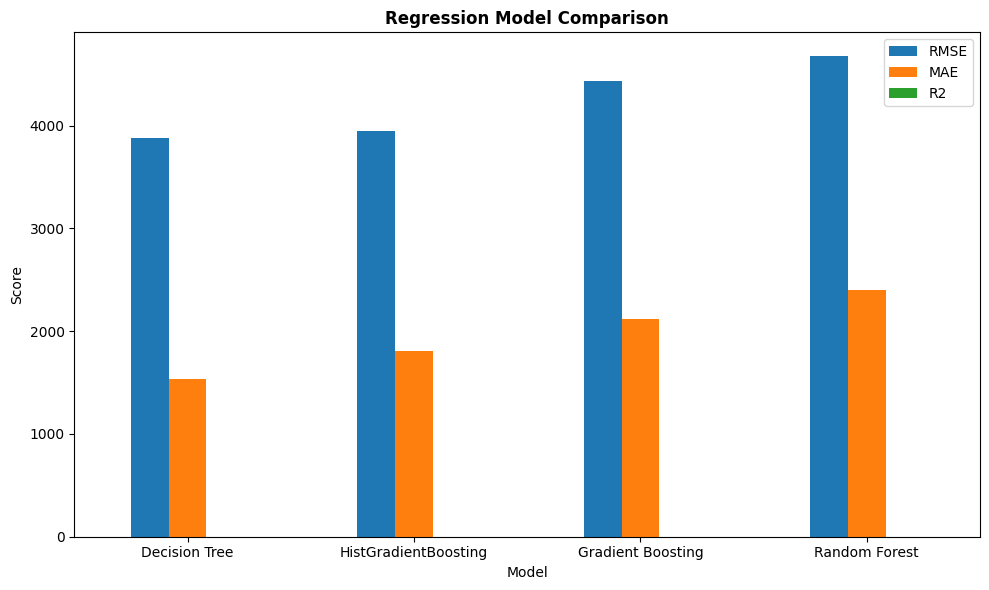

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Regression Model Comparison", fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

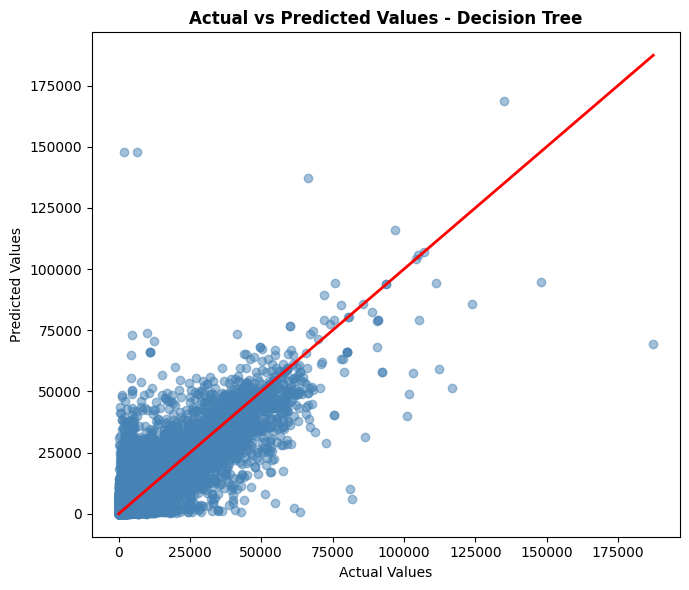

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    y_test_cleaned,
    y_pred_dt,
    alpha=0.5,
    color="steelblue"
)

# Perfect prediction line
plt.plot(
    [y_test_cleaned.min(), y_test_cleaned.max()],
    [y_test_cleaned.min(), y_test_cleaned.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values - Decision Tree", fontweight="bold")

plt.tight_layout()
plt.show()

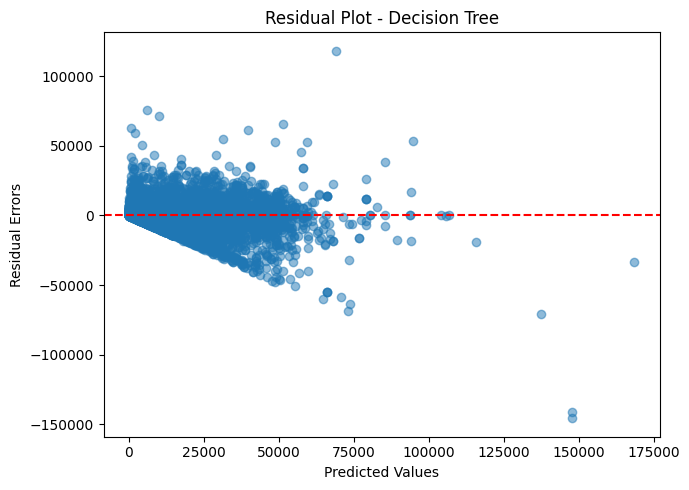

In [ ]:

errors = y_test_cleaned - y_pred_dt

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred_dt,
    errors,
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")

plt.title("Residual Plot - Decision Tree")

plt.tight_layout()
plt.show()

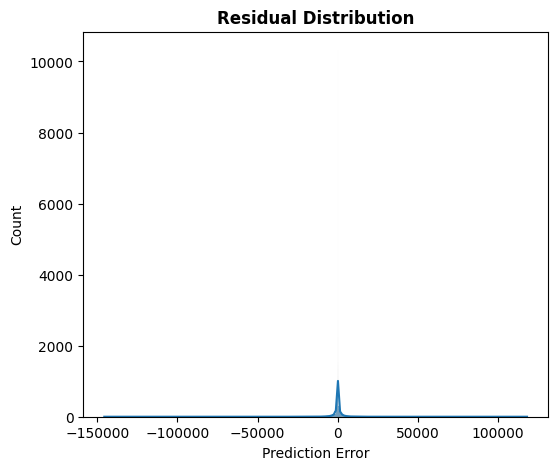

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution", fontweight="bold")
plt.xlabel("Prediction Error")

plt.show()

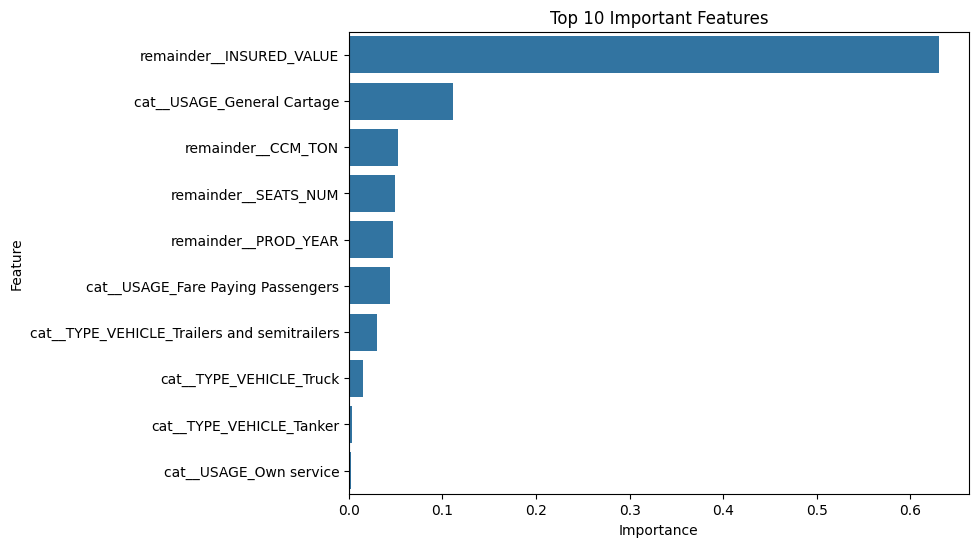

In [ ]:
importances = decision_tree_model.named_steps["model"].feature_importances_

# Get feature names after preprocessing
feature_names_after_preprocessing = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names_after_preprocessing,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
model = decision_tree_model.named_steps["model"]

feature_names = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
25,remainder__INSURED_VALUE,0.631054
17,cat__USAGE_General Cartage,0.111745
27,remainder__CCM_TON,0.052914
26,remainder__SEATS_NUM,0.049078
28,remainder__PROD_YEAR,0.047260
15,cat__USAGE_Fare Paying Passengers,0.043408
9,cat__TYPE_VEHICLE_Trailers and semitrailers,0.030196
10,cat__TYPE_VEHICLE_Truck,0.014631
6,cat__TYPE_VEHICLE_Tanker,0.002941
21,cat__USAGE_Own service,0.002358
